In [1]:
# Windows asyncio fix - MUST BE FIRST CELL
import sys
if sys.platform == 'win32':
    try:
        import nest_asyncio
        nest_asyncio.apply()
        print('✓ Windows asyncio fix applied')
    except ImportError:
        print('⚠ nest_asyncio not installed. Run: pip install nest-asyncio')


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
import sys
if sys.platform == 'win32':
    import asyncio
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
import gc
gc.collect()

10

In [4]:
# Load JSON results from both models
from path_utils import get_output_path

results_dir = get_output_path('3_xg_boost')

with open(results_dir / "results_old.json", "r") as f:
    old = json.load(f)

with open(results_dir / "results_new.json", "r") as f:
    new = json.load(f)

print("Old model results:", list(old.keys()))
print("New model results:", list(new.keys()))

Old model results: ['raw', 'five', 'quarter', 'hourly', 'daily']
New model results: ['five', 'quarter', 'hourly', 'daily']


In [5]:
# Convert to DataFrame for easier analysis
df_old = pd.DataFrame(old).T
df_new = pd.DataFrame(new).T

# Remove raw data since mesonet only starts from five minute aggregation
keep = ["five", "quarter", "hourly", "daily"]

df_old = df_old.loc[keep]
df_new = df_new.loc[keep]

print("\nNYISO-only model metrics:")
print(df_old)
print("\nNYISO + Mesonet model metrics:")
print(df_new)



NYISO-only model metrics:
             MAPE        MAE       RMSE        R2    Time_s
five     0.332991   5.156098   6.996352  0.999379  3.629306
quarter  0.452332   7.230641  10.282904  0.998658  1.656767
hourly   2.547015  39.766379  50.167716  0.967950  0.645990
daily    4.374970  69.212783  93.993051  0.822618  0.185764

NYISO + Mesonet model metrics:
             MAPE        MAE       RMSE        R2    Time_s
five     0.267096   4.162006   5.865176  0.999563  5.638754
quarter  0.369278   5.780806   7.991003  0.999189  4.328334
hourly   1.642637  25.102590  32.988333  0.986126  1.391726
daily    3.110799  48.429803  65.499512  0.913862  0.456352


In [6]:
# Calculate improvement percentages
improvement = pd.DataFrame(index=keep)

for metric in ["MAPE", "MAE", "RMSE"]:
    # For these metrics, lower is better
    improvement[f"{metric}_improvement_%"] = ((df_old[metric] - df_new[metric]) / df_old[metric] * 100)

# For R², higher is better
improvement["R2_improvement_%"] = ((df_new["R2"] - df_old["R2"]) / df_old["R2"] * 100)

print("\nImprovement from adding Mesonet weather data:")
print(improvement.round(2))



Improvement from adding Mesonet weather data:
         MAPE_improvement_%  MAE_improvement_%  RMSE_improvement_%  \
five                  19.79              19.28               16.17   
quarter               18.36              20.05               22.29   
hourly                35.51              36.87               34.24   
daily                 28.90              30.03               30.31   

         R2_improvement_%  
five                 0.02  
quarter              0.05  
hourly               1.88  
daily               11.09  


## Comparison Plots
Visualize performance metrics across different time aggregations

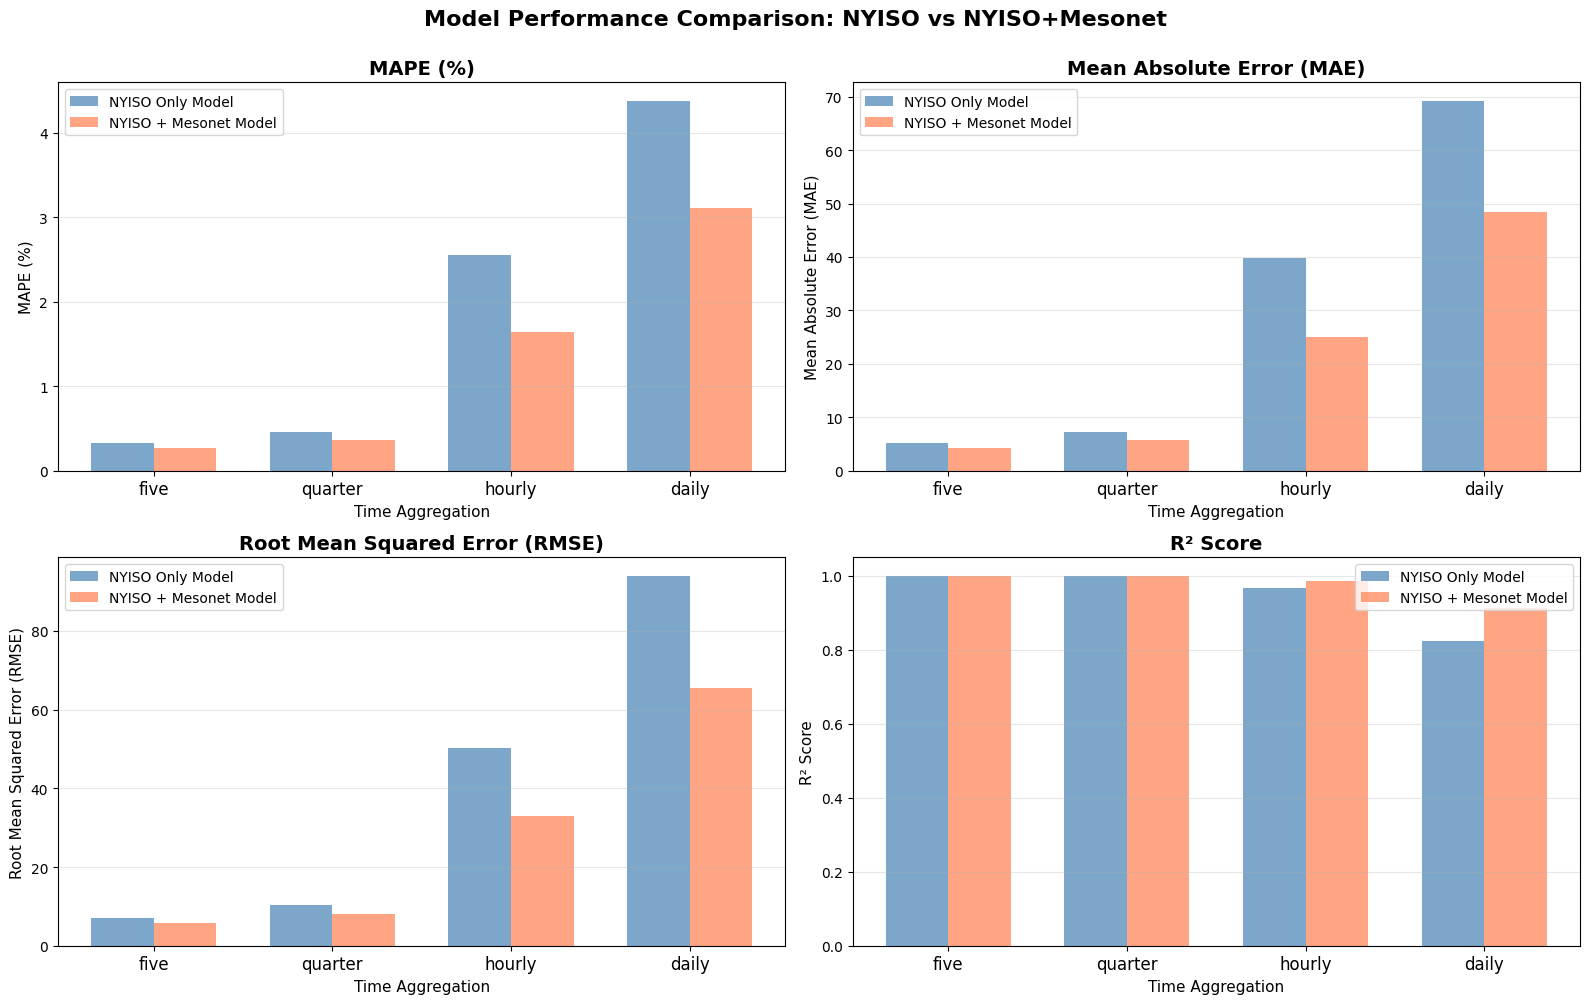

In [7]:
metrics = ["MAPE", "MAE", "RMSE", "R2"]
titles = {
    "MAPE": "MAPE (%)",
    "MAE":  "Mean Absolute Error (MAE)",
    "RMSE": "Root Mean Squared Error (RMSE)",
    "R2":   "R² Score"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

x = np.arange(len(keep))  # positions
bar_width = 0.35

for i, metric in enumerate(metrics):
    ax = axes[i]

    old_vals = df_old[metric].values
    new_vals = df_new[metric].values

    bars1 = ax.bar(x - bar_width/2, old_vals, width=bar_width, 
                   label="NYISO Only Model", alpha=0.7, color='steelblue')
    bars2 = ax.bar(x + bar_width/2, new_vals, width=bar_width, 
                   label="NYISO + Mesonet Model", alpha=0.7, color='coral')

    ax.set_title(titles[metric], fontsize=14, weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(keep, fontsize=12)
    ax.set_xlabel("Time Aggregation", fontsize=11)
    ax.set_ylabel(titles[metric], fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    # Improve spacing for tight metrics
    if metric == "R2":
        ax.set_ylim(0, 1.05)

    ax.legend(loc='best')

plt.suptitle("Model Performance Comparison: NYISO vs NYISO+Mesonet", 
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


## Summary Statistics

In [8]:
# Calculate average improvement across all aggregations
avg_improvement = improvement.mean()
print("Average improvement across all time aggregations:")
print(avg_improvement.round(2))

# Find best performing aggregation for each model
print("\n" + "="*60)
print("Best performing time aggregation:")
print("="*60)
for metric in ["MAPE", "MAE", "RMSE"]:
    old_best = df_old[metric].idxmin()
    new_best = df_new[metric].idxmin()
    print(f"{metric}:")
    print(f"  NYISO-only: {old_best} ({df_old.loc[old_best, metric]:.4f})")
    print(f"  + Mesonet:  {new_best} ({df_new.loc[new_best, metric]:.4f})")

# R² - higher is better
old_best = df_old["R2"].idxmax()
new_best = df_new["R2"].idxmax()
print(f"R²:")
print(f"  NYISO-only: {old_best} ({df_old.loc[old_best, 'R2']:.4f})")
print(f"  + Mesonet:  {new_best} ({df_new.loc[new_best, 'R2']:.4f})")


Average improvement across all time aggregations:
MAPE_improvement_%    25.64
MAE_improvement_%     26.56
RMSE_improvement_%    25.75
R2_improvement_%       3.26
dtype: float64

Best performing time aggregation:
MAPE:
  NYISO-only: five (0.3330)
  + Mesonet:  five (0.2671)
MAE:
  NYISO-only: five (5.1561)
  + Mesonet:  five (4.1620)
RMSE:
  NYISO-only: five (6.9964)
  + Mesonet:  five (5.8652)
R²:
  NYISO-only: five (0.9994)
  + Mesonet:  five (0.9996)


In [9]:
# Create detailed comparison table
comparison_table = pd.DataFrame()
for metric in metrics:
    comparison_table[f"{metric}_old"] = df_old[metric]
    comparison_table[f"{metric}_new"] = df_new[metric]
    if metric in ["MAPE", "MAE", "RMSE"]:
        comparison_table[f"{metric}_Δ%"] = improvement[f"{metric}_improvement_%"]
    else:
        comparison_table[f"{metric}_Δ%"] = improvement[f"{metric}_improvement_%"]

print("\nDetailed Comparison Table:")
print(comparison_table.round(4))

# Save to CSV
comparison_table.to_csv("model_comparison_detailed.csv")
print("\nSaved detailed comparison to: model_comparison_detailed.csv")



Detailed Comparison Table:
         MAPE_old  MAPE_new  MAPE_Δ%  MAE_old  MAE_new   MAE_Δ%  RMSE_old  \
five       0.3330    0.2671  19.7888   5.1561   4.1620  19.2799    6.9964   
quarter    0.4523    0.3693  18.3613   7.2306   5.7808  20.0513   10.2829   
hourly     2.5470    1.6426  35.5074  39.7664  25.1026  36.8748   50.1677   
daily      4.3750    3.1108  28.8955  69.2128  48.4298  30.0277   93.9931   

         RMSE_new  RMSE_Δ%  R2_old  R2_new    R2_Δ%  
five       5.8652  16.1681  0.9994  0.9996   0.0185  
quarter    7.9910  22.2885  0.9987  0.9992   0.0532  
hourly    32.9883  34.2439  0.9680  0.9861   1.8777  
daily     65.4995  30.3145  0.8226  0.9139  11.0920  

Saved detailed comparison to: model_comparison_detailed.csv
